In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

2025-06-25 22:31:34.216626: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-25 22:31:34.462997: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-25 22:31:34.582414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750890694.890781   13047 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750890694.986551   13047 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750890695.687077   13047 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:
## Carregamento
df=pd.read_csv('../data/diabetes_dataset.csv')

In [ ]:
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [11]:
# Limpeza e preparação dos dados
df_clean = df.drop(['year', 'location', 'smoking_history', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other'], axis=1)
df_clean = pd.get_dummies(df_clean, columns=['gender'], drop_first=True)
if 'gender_Male' in df_clean.columns:
    df_clean['gender_Male'] = df_clean['gender_Male'].astype(int)
if 'gender_Other' in df_clean.columns:
    df_clean['gender_Other'] = df_clean['gender_Other'].astype(int)

In [12]:
X=df[['age','hypertension','hbA1c_level','bmi','heart_disease','blood_glucose_level']]
y=df['diabetes']
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.30,random_state=101)

In [13]:
# Scalling
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.fit_transform(X_test)

Treinamento

Epoch 1/100


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.2364 - val_loss: 0.1188
Epoch 2/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1161 - val_loss: 0.1154
Epoch 3/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1134 - val_loss: 0.1143
Epoch 4/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1155 - val_loss: 0.1136
Epoch 5/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.1135 - val_loss: 0.1136
Epoch 6/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1074 - val_loss: 0.1126
Epoch 7/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1110 - val_loss: 0.1117
Epoch 8/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1096 - val_loss: 0.1113
Epoch 9/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1084 - val_loss: 0.1109
Epoch 10/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1114 - val_loss: 0.1102
Epoch 11/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1074 - val_loss: 0.1101
Epoch 12/100
2188/2188 ━━━━━━━━

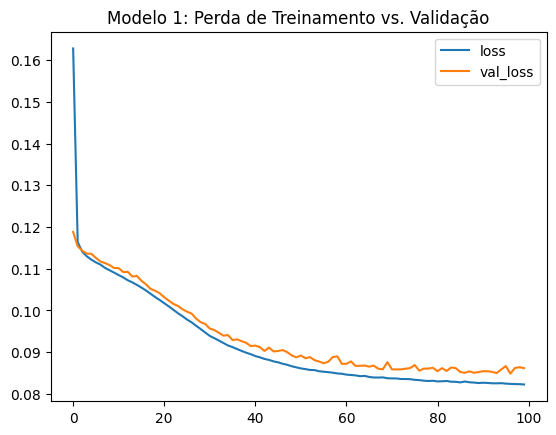

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step
--- Relatório de Classificação - Modelo 1 ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27422
           1       0.98      0.68      0.80      2578

    accuracy                           0.97     30000
   macro avg       0.97      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000

Acurácia: 0.9710


In [20]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

# Modelo 1: Rede Neural Básica de 2 Camadas Ocultas
model_1 = Sequential()
model_1.add(Dense(units=30, activation='relu')) # Camada oculta 1
model_1.add(Dense(units=15, activation='relu')) # Camada oculta 2
model_1.add(Dense(units=1, activation='sigmoid')) # Camada de saída

model_1.compile(loss="binary_crossentropy", optimizer="SGD")

# Treinamento do modelo
model_1.fit(x=X_train, 
            y=y_train, 
            epochs=100,
            validation_data=(X_test, y_test), 
            callbacks=[early_stop])

# Visualização da perda (loss) durante o treinamento
losses_1 = pd.DataFrame(model_1.history.history)
losses_1.plot()
plt.title("Modelo 1: Perda de Treinamento vs. Validação")
plt.show()

# Avaliação do Modelo 1
predictions_1 = (model_1.predict(X_test) > 0.5).astype("int32")

print("--- Relatório de Classificação - Modelo 1 ---")
print(classification_report(y_test, predictions_1))
print(f"Acurácia: {accuracy_score(y_test, predictions_1):.4f}")

Epoch 1/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1587 - val_loss: 0.0956
Epoch 2/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0935 - val_loss: 0.0876
Epoch 3/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0872 - val_loss: 0.0896
Epoch 4/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0863 - val_loss: 0.0876
Epoch 5/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0816 - val_loss: 0.0862
Epoch 6/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0829 - val_loss: 0.0851
Epoch 7/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0836 - val_loss: 0.0842
Epoch 8/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0829 - val_loss: 0.0835
Epoch 9/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0830 - val_loss: 0.0838
Epoch 10/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0840 - val_loss: 0.0863
Epoch 11/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0819 - val_loss: 0.0924
Epoch 12/100
2188/2

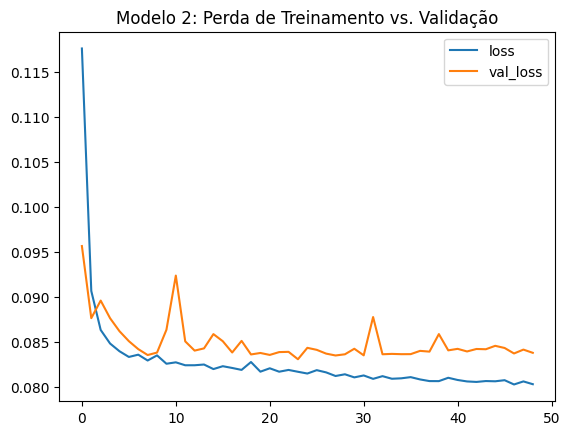

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step
--- Relatório de Classificação - Modelo 2 ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27422
           1       0.98      0.68      0.80      2578

    accuracy                           0.97     30000
   macro avg       0.98      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000

Acurácia: 0.9714


In [21]:
# Modelo 2: Rede Neural de 4 Camadas Ocultas
model_2 = Sequential()
model_2.add(Dense(units=64, activation='relu')) # Camada oculta 1
model_2.add(Dense(units=32, activation='relu')) # Camada oculta 2
model_2.add(Dense(units=16, activation='relu')) # Camada oculta 3
model_2.add(Dense(units=8, activation='relu'))  # Camada oculta 4
model_2.add(Dense(units=1, activation='sigmoid')) # Camada de saída

model_2.compile(loss='binary_crossentropy', optimizer='adam')

# Treinamento do modelo
model_2.fit(x=X_train, 
            y=y_train, 
            epochs=100,
            validation_data=(X_test, y_test), 
            callbacks=[early_stop])

# Visualização da perda (loss) durante o treinamento
losses_2 = pd.DataFrame(model_2.history.history)
losses_2.plot()
plt.title("Modelo 2: Perda de Treinamento vs. Validação")
plt.show()

# Avaliação do Modelo 2
predictions_2 = (model_2.predict(X_test) > 0.5).astype("int32")

print("--- Relatório de Classificação - Modelo 2 ---")
print(classification_report(y_test, predictions_2))
print(f"Acurácia: {accuracy_score(y_test, predictions_2):.4f}")


Epoch 1/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1954 - val_loss: 0.1156
Epoch 2/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1109 - val_loss: 0.1117
Epoch 3/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1090 - val_loss: 0.1071
Epoch 4/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1047 - val_loss: 0.1007
Epoch 5/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0975 - val_loss: 0.0971
Epoch 6/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0927 - val_loss: 0.0938
Epoch 7/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0893 - val_loss: 0.0915
Epoch 8/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0879 - val_loss: 0.0888
Epoch 9/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0874 - val_loss: 0.0875
Epoch 10/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0842 - val_loss: 0.0867
Epoch 11/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0815 - val_loss: 0.0855
Epoch 12/100
2188/2

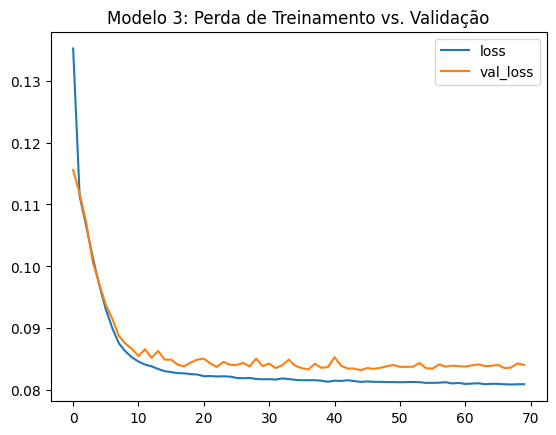

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step
--- Relatório de Classificação - Modelo 3 ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27422
           1       0.98      0.68      0.80      2578

    accuracy                           0.97     30000
   macro avg       0.98      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000

Acurácia: 0.9713


In [22]:
# Modelo 3: Rede com Função de Ativação `tanh`

model_3 = Sequential()
model_3.add(Dense(units=30, activation='tanh')) # Camada oculta 1 com 'tanh'
model_3.add(Dense(units=15, activation='tanh')) # Camada oculta 2 com 'tanh'
model_3.add(Dense(units=1, activation='sigmoid')) # Camada de saída

model_3.compile(loss='binary_crossentropy', optimizer='adam')


# Treinamento do modelo
model_3.fit(x=X_train, 
            y=y_train, 
            epochs=100,
            validation_data=(X_test, y_test), 
            callbacks=[early_stop])


# Visualização da perda (loss) durante o treinamento
losses_3 = pd.DataFrame(model_3.history.history)
losses_3.plot()
plt.title("Modelo 3: Perda de Treinamento vs. Validação")
plt.show()

# Avaliação do Modelo 3
predictions_3 = (model_3.predict(X_test) > 0.5).astype("int32")

print("--- Relatório de Classificação - Modelo 3 ---")
print(classification_report(y_test, predictions_3))
print(f"Acurácia: {accuracy_score(y_test, predictions_3):.4f}")


Salvar Modelos como artefato

In [23]:
# Modelo 1
filepath_model_1 = 'diabetes_model_1.weights.h5'
model_1.save_weights(filepath_model_1)

# Modelo 2
filepath_model_2 = 'diabetes_model_2.weights.h5'
model_2.save_weights(filepath_model_2)

# Modelo 3
filepath_model_3 = 'diabetes_model_3.weights.h5'
model_3.save_weights(filepath_model_3)
